In [12]:
import os, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__)
print("GPU доступно:", len(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.20.0
GPU доступно: 0


In [13]:
base_dir = r'C:\Users\user\Desktop\Food Classification dataset'
classes = ['Crispy Chicken', 'Taco', 'chai', 'cheesecake', 'Donut', 'dal_makhani', 'Hot Dog', 'samosa', 'sushi', 'Taquito']
class_to_idx = {cls: i for i, cls in enumerate(classes)}

all_files = []
all_labels = []

for cls in classes:
    cls_path = os.path.join(base_dir, cls)
    if os.path.exists(cls_path):
        files = glob.glob(os.path.join(cls_path, '*.jpg')) + \
                glob.glob(os.path.join(cls_path, '*.jpeg'))  
        all_files.extend(files)
        all_labels.extend([class_to_idx[cls]] * len(files))
    else:
        print(f"Папка не найдена: {cls_path}")

print(f"Всего изображений: {len(all_files)}")
print("Пример меток:", Counter(all_labels))




Всего изображений: 10397
Пример меток: Counter({6: 1531, 0: 1500, 1: 1500, 9: 1500, 4: 1483, 3: 1000, 8: 1000, 2: 344, 5: 295, 7: 244})


In [14]:
IMG_SIZE = 100
BATCH_SIZE = 16  

def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)  
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.convert_image_dtype(img, tf.float32)  
    img = tf.ensure_shape(img, [IMG_SIZE, IMG_SIZE, 3])  
    return img, tf.cast(label, tf.int32)

dataset = tf.data.Dataset.from_tensor_slices((all_files, all_labels))
dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=4)  

train_size = int(0.8 * len(all_files))
train_ds = dataset.take(train_size).shuffle(500).batch(BATCH_SIZE).prefetch(2)
test_ds = dataset.skip(train_size).batch(BATCH_SIZE).prefetch(2)



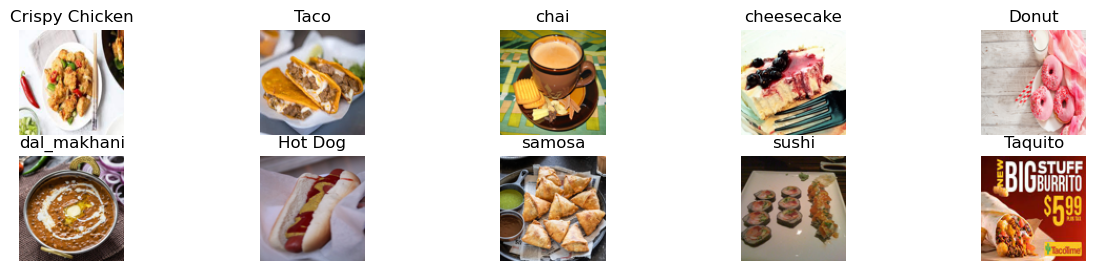

In [16]:
plt.figure(figsize=(15, 3))
class_names = ['Crispy Chicken', 'Taco', 'chai', 'cheesecake', 'Donut', 'dal_makhani', 'Hot Dog', 'samosa', 'sushi', 'Taquito']

for cls_idx, cls in enumerate(classes[:10]):
    cls_path = os.path.join(base_dir, cls)
    files = glob.glob(os.path.join(cls_path, '*.jpg')) + glob.glob(os.path.join(cls_path, '*.jpeg'))
    if files:
        img_path = files[0]  
        img = Image.open(img_path).convert('RGB').resize((100,100))
        img_array = np.array(img, dtype=np.float32) / 255.0
        
        plt.subplot(2, 5, cls_idx+1)
        plt.imshow(img_array)  
        plt.title(class_names[cls_idx])
        plt.axis('off')

plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


for img, label in train_ds.take(1):
    plt.figure(figsize=(10,5))
    for i in range(5):
        ax = plt.subplot(2,5,i+1)
        aug_img = data_augmentation(img, training=True)
        plt.imshow(aug_img[0].numpy())
        plt.axis('off')
    plt.show()

In [ ]:
model = models.Sequential([
    data_augmentation,  
    layers.Conv2D(32, 3, activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(), 
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    layers.GlobalAveragePooling2D(),  
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')  
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',  
              metrics=['accuracy'])
model.summary()

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

history = model.fit(train_ds, epochs=50, validation_data=test_ds, callbacks=callbacks)
test_loss, test_acc = model.evaluate(test_ds)
print(f"Тестовая точность: {test_acc:.2%}")